In [1]:
import torch
from torch import nn
from torch.nn import functional as F

import matplotlib.pyplot as plt
import numpy as np

In [2]:
class MNISTMLP(nn.Module):
    
    def __init__(self, harmonic: bool, scale: float=10**.5, norm: float=None):
        super().__init__()
        # self.fc1 = nn.Linear(28*28, 10)
        self.w = nn.Parameter(torch.empty((28*28, 10)))
        nn.init.normal_(self.w, mean=0, std=1/28.)
        self.harmonic = harmonic
        self.logits = torch.tensor(0)
        self.norm = norm
        self.scale = scale

    def forward(self, x):
        # input x must have shape: (batch_size, 28*28)

        # y shape: (batch_size, 3)
        if self.harmonic:
            if self.norm == float('inf'):
                self.logits, _ = torch.max(torch.abs(x[..., None, :] - self.w.T), dim=-1)
            else:
                self.logits = torch.norm(x[..., None, :] - self.w.T, dim=-1, p=self.norm)
            y = 1/(self.logits**self.scale)
            y = y/y.sum(dim=-1, keepdims=True)
        else:
            self.logits = x @ self.w
            y = F.softmax(self.logits, dim=-1)

        return y
    
x = torch.randn(1, 28*28)
mnist_mlp = MNISTMLP(harmonic=True, norm=float('inf'))
mnist_mlp(x)

tensor([[0.1008, 0.1060, 0.1027, 0.1015, 0.0945, 0.1002, 0.0995, 0.0961, 0.1006,
         0.0981]], grad_fn=<DivBackward0>)

In [5]:
import torchvision
import torchvision.transforms as transforms

DOWNLOAD_PATH = '../datasets'

# normalize so that the mean of the data is zero and the variance is one
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) 
])

train_val = torchvision.datasets.MNIST(root=DOWNLOAD_PATH, train=True, download=True, transform=transform)
test = torchvision.datasets.MNIST(root=DOWNLOAD_PATH, train=False, download=True, transform=transform)
train, val = torch.utils.data.random_split(train_val, [55000, 5000])

len(train), len(val), len(test)

100.0%
100.0%
100.0%
100.0%


(55000, 5000, 10000)

In [6]:
from torch.utils.data import DataLoader

batch_size = 64
train_loader = DataLoader(train, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test, batch_size=len(test), shuffle=True)
val_loader = DataLoader(val, batch_size=len(val), shuffle=True)

In [7]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [8]:
def train_MNIST(model, lr, epochs, verbose=False):
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    train_history = []
    val_history = []

    for e in range(epochs):
        batch_history = []
        # TRAIN STEP
        for images, labels in train_loader:
            # convert images to the correct device (GPU or CPU)
            images, labels = images.flatten(start_dim=1).to(device), labels.to(device)
            # predict and compute loss
            preds = model(images)
            loss = F.nll_loss(torch.log(preds), labels)
            batch_history.append(loss.item())
            # optimization step
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        train_history.append(np.mean(batch_history))

        batch_history = []
        # VALIDATION STEP
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.flatten(start_dim=1).to(device), labels.to(device)
                preds = model(images)
                loss = F.nll_loss(torch.log(preds), labels)
                batch_history.append(loss.item())
            val_history.append(np.mean(batch_history))
        
        if verbose: print(f"epoch: {e}\ttrain loss: {train_history[-1]:.4f}\tval loss: {val_history[-1]:.4f}")
    
    return train_history, val_history

In [10]:
import math

device = 'cuda' if torch.cuda.is_available() else 'cpu'
EPOCHS = 10
learning_rate = 0.001

model = MNISTMLP(harmonic=False).to(device)

In [11]:
train_histories, val_histories = [], []

train_history, val_history = train_MNIST(model, learning_rate, EPOCHS, verbose=True)

train_histories.append(train_history)
val_histories.append(val_history)

epoch: 0	train loss: 0.4815	val loss: 0.3796
epoch: 1	train loss: 0.3298	val loss: 0.3495
epoch: 2	train loss: 0.3119	val loss: 0.3340
epoch: 3	train loss: 0.3019	val loss: 0.3307
epoch: 4	train loss: 0.2951	val loss: 0.3210
epoch: 5	train loss: 0.2898	val loss: 0.3273
epoch: 6	train loss: 0.2890	val loss: 0.3187
epoch: 7	train loss: 0.2826	val loss: 0.3554
epoch: 8	train loss: 0.2818	val loss: 0.3134
epoch: 9	train loss: 0.2787	val loss: 0.3114


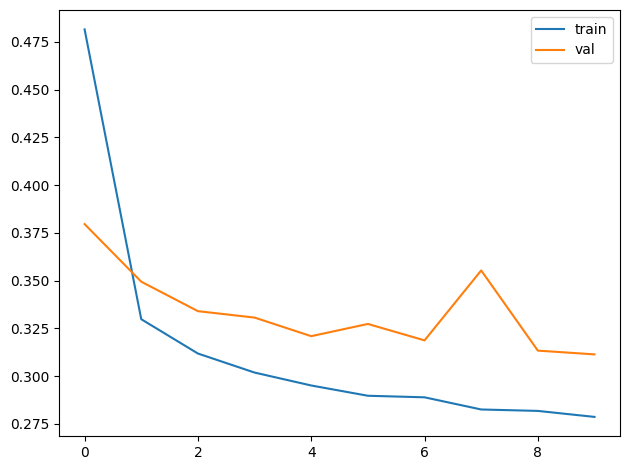

In [12]:
plt.plot(train_histories[0], label='train')
plt.plot(val_histories[0], label='val')
plt.legend()

plt.tight_layout()

In [13]:


test_acc, test_loss = 0, 0
# VALIDATION STEP
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.flatten(start_dim=1).to(device), labels.to(device)
        preds = model(images)
        loss = F.nll_loss(torch.log(preds), labels)
        test_loss += loss.item()
        test_acc += sum(preds.argmax(dim=-1) == labels).item()

test_loss, test_acc / len(test)

(0.2848886549472809, 0.9187)

In [19]:
logits = model.logits.detach().cpu().numpy()

logits.shape

(10000, 10)

In [20]:
def SRM(thetas, DL, eps, alpha, beta):

    m = DL.shape[1]

    bi = np.zeros((m,))
    bi[alpha] = 1
    bj = np.zeros((m,))
    bj[beta] = 1

    bivector = 0.5 * (np.outer(bi, bj) - np.outer(bj, bi))
    eigvals, eigvecs = np.linalg.eig(bivector)

    di = np.diag_indices(m)
    Lambda = np.zeros((m, m), dtype=np.complex64)
    Lambda[di] = eigvals

    R_ij = eigvecs @ np.exp(thetas[..., None, None] * Lambda) @ np.conj(eigvecs.T)

    freqs = np.sum((DL @ R_ij @ bi) >= eps, axis=1) / DL.shape[0]
    return freqs

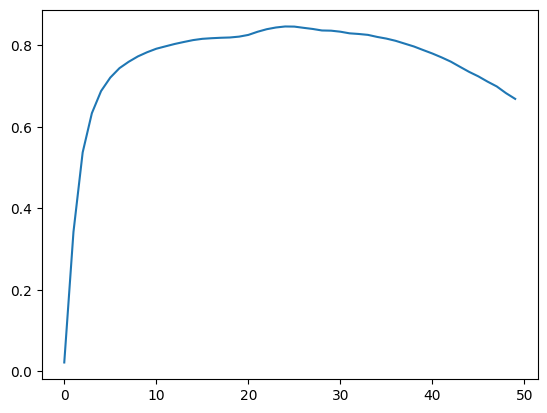

In [26]:
thetas = np.linspace(0.1, 2*np.pi, 50)
eps = 0.9
alpha, beta = 0, 1

freqs = SRM(thetas, logits, eps, alpha, beta)
plt.plot(freqs)